In [1]:
import json
import re
from typing import Any, Dict, List

import dvc.api
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
from matplotlib import pyplot as plt

In [2]:
metrics_commits = {
    'CYFRAGOVPL/Llama-PLLuM-8B-instruct': 'c9e5cdd13e9dfa0132091f748107d281968f1b6a',
    'speakleash/Bielik-11B-v2.2-Instruct': '3c8b0959adf5a6c89e71e0b9e7fba5f9c104bc78',
    'GPT-4o-mini': '84bd0e7d9e3f57e43d555694e798e6185b494730'
}

metrics_dicts = {k: dvc.api.metrics_show(rev=sha) for k, sha in metrics_commits.items()}

In [3]:
measuring_strategies = ['Ent_type', 'Partial', 'Strict', 'Exact']
values = {k: [v['total_f1'][s] for s in measuring_strategies] for k, v in metrics_dicts.items()}

/tmp/ipykernel_199148/2627240942.py:19: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


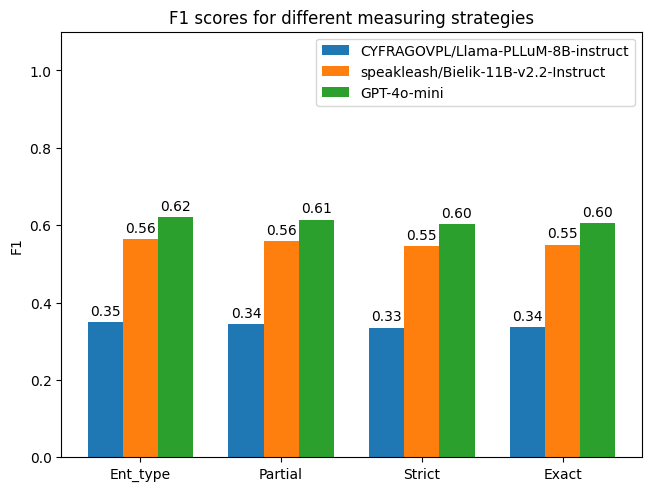

In [4]:



def plot_bar_grouped(x_labels: List[str], values: Dict[str, List[float]], ax_kwargs: Dict[str, Any] = {}):
    x = np.arange(len(x_labels))  # the label locations
    width = 0.25  # the width of the bars
    multiplier = 0

    fig, ax = plt.subplots(layout='constrained')

    for attribute, measurement in values.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3, fmt='%.2f')
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set(**ax_kwargs)
    ax.set_xticks(x + width, x_labels)
    ax.legend(loc='best')

    fig.show()


plot_bar_grouped(measuring_strategies, values, ax_kwargs={'ylabel': 'F1', 'title': 'F1 scores for different measuring strategies', 'ylim': (0,1.1)})

In [5]:
total_found_objects = ['Subjects', 'Predicates', 'Objects', 'Full_triples']
values = {k: [v['total_found_strict_or_partial_percent'][s.lower()] for s in total_found_objects] for k, v in metrics_dicts.items()}

/tmp/ipykernel_199148/2627240942.py:19: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


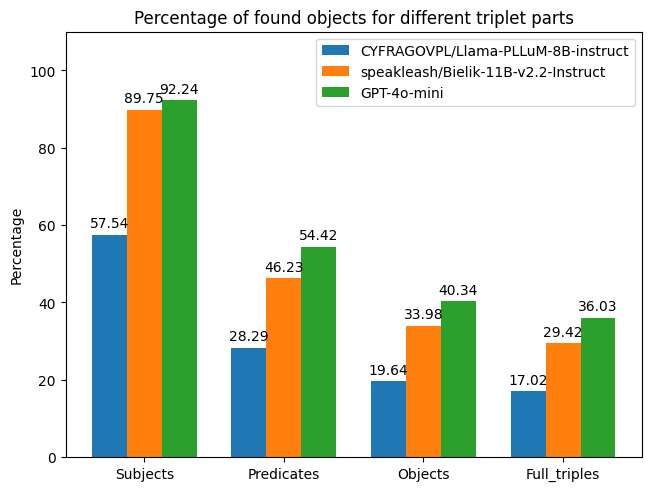

In [6]:
plot_bar_grouped(total_found_objects, values, ax_kwargs={'ylabel': 'Percentage', 'title': 'Percentage of found objects for different triplet parts', 'ylim': (0,110)})

In [7]:



def get_extracted_relations(commit:str):
    with dvc.api.open(
        'data/edc_baseline/cands.xml',
        rev=commit
    ) as f:
        cands = f.read()
        # Parse the XML data
        soup = BeautifulSoup(cands, "xml")

        # Extract all gtriple elements
        cands = [gtriple.text for gtriple in soup.find_all("gtriple")]

    with dvc.api.open(
        'data/edc_baseline/refs.xml',
        rev=commit
    ) as f:
        refs = f.read()
        # Parse the XML data
        soup = BeautifulSoup(refs, "xml")

        # Extract all gtriple elements
        refs = [otriple.text for otriple in soup.find_all("otriple")]

    with dvc.api.open(
        'data/edc_baseline/extracted_relations.json',
        rev=commit
    ) as f:
        responses = json.loads(f.read())['responses']
    
    return dict(cands=cands, refs=refs, responses=responses)


extracted_relations = {k: get_extracted_relations(v) for k, v in metrics_commits.items()}

In [8]:

pattern = r"^.+\s\|\s.+\s\|\s.+$"

def is_valid_triple(triple:str):
    return bool(re.match(pattern, triple))

In [9]:
number_of_invalid_triples = {k: sum([not is_valid_triple(triple) for triple in v['cands']]) for k, v in extracted_relations.items()}

In [10]:
number_of_invalid_triples

{'CYFRAGOVPL/Llama-PLLuM-8B-instruct': 6070,
 'speakleash/Bielik-11B-v2.2-Instruct': 601,
 'GPT-4o-mini': 308}

In [11]:
def plot_bar_ungrouped(x_labels: List[str], values: List[float], ax_kwargs: Dict[str, Any] = {}, xticks_kwargs: Dict[str, Any] = {}):
    x = np.arange(len(x_labels))  # the label locations
    width = 0.25  # the width of the bars

    fig, ax = plt.subplots()

    rects = ax.bar(x, values, width)
    ax.bar_label(rects, padding=3, fmt='%.2f')

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set(**ax_kwargs)
    ax.set_xticks(x, x_labels, **xticks_kwargs)

    fig.show()

/tmp/ipykernel_199148/3399059460.py:14: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


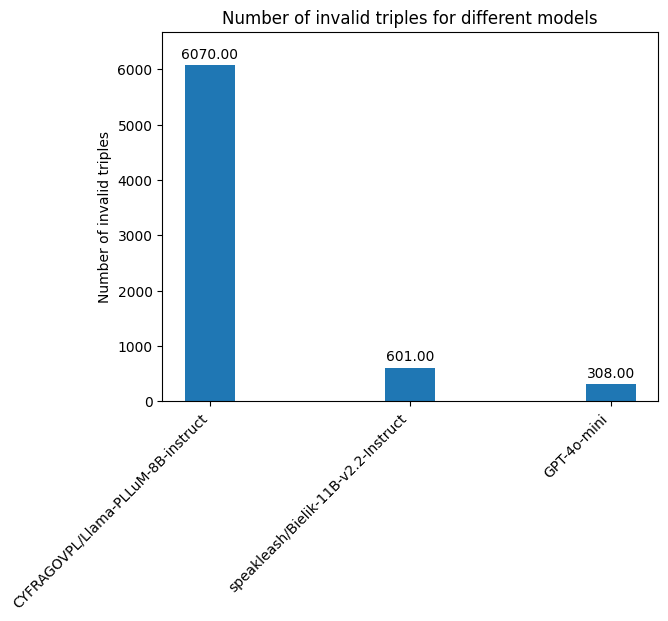

In [12]:
plot_bar_ungrouped(list(number_of_invalid_triples.keys()), list(number_of_invalid_triples.values()), ax_kwargs={'ylabel': 'Number of invalid triples', 'title': 'Number of invalid triples for different models', 'ylim': (0,max(number_of_invalid_triples.values())*1.1)}, xticks_kwargs={'rotation': 45, 'ha': 'right'})

In [13]:
extracted_relations_pllum = pd.DataFrame(extracted_relations['CYFRAGOVPL/Llama-PLLuM-8B-instruct'])
extracted_relations_pllum['is_valid'] = extracted_relations_pllum.cands.apply(is_valid_triple)
extracted_relations_pllum

,cands,refs,responses,is_valid
0,Richard Herd | miejsce urodzenia | Los Angeles,Richard Herd | zawód | Aktor,"['Richard Herd','miejsce urodzenia', 'Los Ange...",True
1,Saint Clement | lokalizacja | Jersey,Saint Clement | lokalizacja | Wyspy Normandzkie,"['Saint Clement', 'lokalizacja', 'Jersey']",True
2,DJ Feel-X | zawód | DJ,DJ Feel-X | zawód | Producent muzyczny,"[[DJ Feel-X, zawód, DJ]]",True
3,Sean Kanan | zawód | Aktor,Sean Kanan | zawód | Aktor,"['Sean Kanan', 'zawód', 'Aktor']",True
4,,Hanna Schygulla | zawód | Aktorka,"[[Hanna Schygulla, miejsce urodzenia, Chorzów ...",False
...,...,...,...,...
17166,,Gmina Emmet | liczba ludności | 178,"[[Gmina Emmet', 'lokalizacja', 'Emmet']",False
17167,Anthony Gatto | miejsce urodzenia | Nowy Jork,Anthony Gatto | zawód | Żongler,"[[Anthony Gatto, miejsce urodzenia, Nowy Jork]]",True
17168,Lucien Guitry | zawód | Aktor,Lucien Guitry | zawód | Aktor,"['Lucien Guitry', 'zawód', 'Aktor']",True
17169,Barry Wilmore | zawód | Pilot wojskowy,Barry Wilmore | zawód | Astronauta,"['Barry Wilmore', 'zawód', 'Pilot wojskowy']",True


In [14]:
pd.DataFrame(extracted_relations_pllum[extracted_relations_pllum.is_valid == False].responses)

,responses
4,"[[Hanna Schygulla, miejsce urodzenia, Chorzów ..."
7,"Nie ma żadnych obiektów, dla których można by ..."
8,Nie udało mi się znaleźć żadnych relacji w tek...
9,"Nie ma wystarczających informacji w tekście, a..."
18,"Nie ma relacji, którą można wyciągnąć z tego t..."
...,...
17160,Nie mogę znaleźć żadnej relacji w podanym tekś...
17164,Nie znaleziono relacji.
17165,"Nie ma relacji, którą można wyciągnąć z tego t..."
17166,"[[Gmina Emmet', 'lokalizacja', 'Emmet']"
